In [1]:
# XGBoost training for 5-minute pickup probability (H3 cells)
# Dataset: PickUP rate/prepared_data/X_features_5min.csv, y_target_5min.csv, meta_5min.csv

from pathlib import Path
import json
import os

import numpy as np
import pandas as pd

# plotting (only for inline evaluation)
import matplotlib.pyplot as plt

# metrics and calibration
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

# model
try:
    from xgboost import XGBClassifier
except Exception as e:
    raise ImportError("xgboost is not installed. Please `pip install xgboost` in this environment.") from e

from sklearn.isotonic import IsotonicRegression
import joblib

DATA_DIR = Path("/Users/jul/Desktop/uni/Data Analytics/Taxi-Income-Optimizer/PickUP rate/prepared_data")
OUT_DIR = DATA_DIR / "models"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

print("Using DATA_DIR=", DATA_DIR)
print("Artifacts will be saved to:", OUT_DIR)



Using DATA_DIR= /Users/jul/Desktop/uni/Data Analytics/Taxi-Income-Optimizer/PickUP rate/prepared_data
Artifacts will be saved to: /Users/jul/Desktop/uni/Data Analytics/Taxi-Income-Optimizer/PickUP rate/prepared_data/models


In [2]:
# Load data
X_path = DATA_DIR / "X_features_5min_optimized.csv"
y_path = DATA_DIR / "y_target_5min_optimized.csv"
meta_path = DATA_DIR / "meta_5min_optimized.csv"

print("Loading:")
print(" -", X_path)
print(" -", y_path)
print(" -", meta_path)

X = pd.read_csv(X_path)
y = pd.read_csv(y_path).iloc[:, 0]
meta = pd.read_csv(meta_path, parse_dates=["time_bin"])  # has time_bin, h3_cell, pickup_cnt

print("Shapes:", X.shape, y.shape, meta.shape)
print("time range:", meta["time_bin"].min(), "->", meta["time_bin"].max())

# Time-based split: last N days for validation
# Choose split on a boundary so validation is strictly later
val_fraction = 0.15
cut_time = meta["time_bin"].quantile(1 - val_fraction)

train_idx = meta["time_bin"] < cut_time
val_idx = meta["time_bin"] >= cut_time

X_train, y_train = X[train_idx].reset_index(drop=True), y[train_idx].reset_index(drop=True)
X_val, y_val = X[val_idx].reset_index(drop=True), y[val_idx].reset_index(drop=True)
meta_train, meta_val = meta[train_idx].reset_index(drop=True), meta[val_idx].reset_index(drop=True)

print("Train/Val sizes:", X_train.shape, X_val.shape)
print("Positive rate train/val:", y_train.mean().round(4), y_val.mean().round(4))

# Optionally hold out a small calibration subset from validation for isotonic
# Here we use all validation for calibration to keep it simple; you can also split
X_cal, y_cal = X_val, y_val



Loading:
 - /Users/jul/Desktop/uni/Data Analytics/Taxi-Income-Optimizer/PickUP rate/prepared_data/X_features_5min_optimized.csv
 - /Users/jul/Desktop/uni/Data Analytics/Taxi-Income-Optimizer/PickUP rate/prepared_data/y_target_5min_optimized.csv
 - /Users/jul/Desktop/uni/Data Analytics/Taxi-Income-Optimizer/PickUP rate/prepared_data/meta_5min_optimized.csv
Shapes: (1394272, 30) (1394272,) (1394272, 3)
time range: 2024-11-08 15:00:00 -> 2024-12-31 23:00:00
Train/Val sizes: (1185022, 30) (209250, 30)
Positive rate train/val: 0.8651 0.8794


In [3]:
# Version-safe training with native xgboost API
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

# weights for imbalance
sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)

dtrain = xgb.DMatrix(X_train, label=y_train, weight=sample_weight, feature_names=list(X_train.columns))
dval   = xgb.DMatrix(X_val,   label=y_val,   feature_names=list(X_val.columns))

params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "eta": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 2,
    "lambda": 1.0,
    "tree_method": "hist",
    "verbosity": 1,
}

watchlist = [(dtrain, "train"), (dval, "val")]
booster = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=2000,
    evals=watchlist,
    early_stopping_rounds=50,
    verbose_eval=50,
)

# Get best iteration robustly across versions
# Predict with xgboost 3.x
best_iteration = getattr(booster, "best_iteration", None)
if best_iteration is None:
    try:
        best_iteration = booster.num_boosted_rounds() - 1
    except Exception:
        best_iteration = 1999  # fallback if unknown

val_proba_raw = booster.predict(dval, iteration_range=(0, int(best_iteration) + 1))

from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
print("Val AUC (raw):", roc_auc_score(y_val, val_proba_raw))
print("Val PR-AUC (raw):", average_precision_score(y_val, val_proba_raw))
print("Brier (raw):", brier_score_loss(y_val, val_proba_raw))

[0]	train-auc:0.86346	val-auc:0.85181
[50]	train-auc:0.89571	val-auc:0.88776
[100]	train-auc:0.91545	val-auc:0.90878
[150]	train-auc:0.91997	val-auc:0.91333
[200]	train-auc:0.92148	val-auc:0.91475
[250]	train-auc:0.92230	val-auc:0.91539
[300]	train-auc:0.92286	val-auc:0.91568
[350]	train-auc:0.92331	val-auc:0.91580
[400]	train-auc:0.92373	val-auc:0.91586
[450]	train-auc:0.92410	val-auc:0.91589
[500]	train-auc:0.92448	val-auc:0.91594
[550]	train-auc:0.92487	val-auc:0.91594
[592]	train-auc:0.92515	val-auc:0.91594
Val AUC (raw): 0.9159554243315025
Val PR-AUC (raw): 0.9864302432459704
Brier (raw): 0.1100669454218682


{'roc_auc_raw': 0.916, 'pr_auc_raw': 0.9864, 'brier_raw': 0.11007, 'roc_auc_cal': 0.9162, 'pr_auc_cal': 0.986, 'brier_cal': 0.05806}


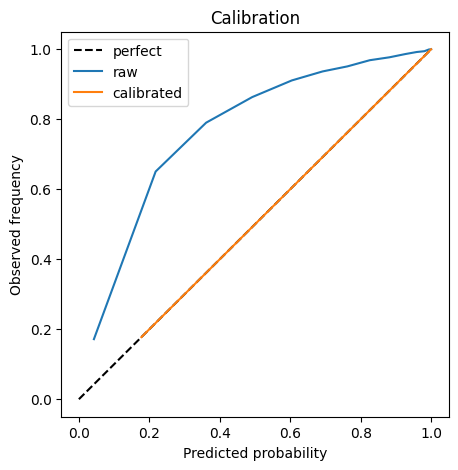

Color thresholds: {'green': 0.6, 'yellow': 0.3, 'red': 0.1}


In [4]:
# Calibrate probabilities (isotonic) and evaluate

# Fit isotonic on validation set
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(val_proba_raw, y_cal)

val_proba_cal = iso.predict(val_proba_raw)

roc_auc_raw = roc_auc_score(y_val, val_proba_raw)
pr_auc_raw = average_precision_score(y_val, val_proba_raw)
brier_raw = brier_score_loss(y_val, val_proba_raw)

roc_auc_cal = roc_auc_score(y_val, val_proba_cal)
pr_auc_cal = average_precision_score(y_val, val_proba_cal)
brier_cal = brier_score_loss(y_val, val_proba_cal)

print({
    "roc_auc_raw": round(roc_auc_raw, 4),
    "pr_auc_raw": round(pr_auc_raw, 4),
    "brier_raw": round(brier_raw, 5),
    "roc_auc_cal": round(roc_auc_cal, 4),
    "pr_auc_cal": round(pr_auc_cal, 4),
    "brier_cal": round(brier_cal, 5),
})

# Optional: plot calibration curve
prob_true, prob_pred = calibration_curve(y_val, val_proba_raw, n_bins=15, strategy="quantile")
prob_true_c, prob_pred_c = calibration_curve(y_val, val_proba_cal, n_bins=15, strategy="quantile")

plt.figure(figsize=(5,5))
plt.plot([0,1], [0,1], "k--", label="perfect")
plt.plot(prob_pred, prob_true, label="raw")
plt.plot(prob_pred_c, prob_true_c, label="calibrated")
plt.xlabel("Predicted probability"); plt.ylabel("Observed frequency"); plt.legend(); plt.title("Calibration"); plt.show()

# Fixed color thresholds (can be tuned later)
# green >= 0.6, yellow 0.3-0.6, red 0.1-0.3, transparent < 0.1
COLOR_THRESHOLDS = {"green": 0.6, "yellow": 0.3, "red": 0.1}
print("Color thresholds:", COLOR_THRESHOLDS)



In [5]:
# Save artifacts: model, calibrator, feature names, thresholds

model_path = OUT_DIR / "xgb_pickup_5min.joblib"
calib_path = OUT_DIR / "isotonic_calibrator.joblib"
feat_path = OUT_DIR / "feature_names.json"
report_path = OUT_DIR / "eval_report.json"
thresholds_path = OUT_DIR / "color_thresholds.json"

booster_path = OUT_DIR / "xgb_pickup_5min.json"
booster.save_model(str(booster_path))
print("Saved Booster:", booster_path)

joblib.dump(iso, calib_path)
json.dump(list(X.columns), open(feat_path, "w"))

report = {
    "num_features": int(X.shape[1]),
    "train_size": int(len(y_train)),
    "val_size": int(len(y_val)),
    "pos_rate_train": float(y_train.mean()),
    "pos_rate_val": float(y_val.mean()),
    "roc_auc_raw": float(roc_auc_raw),
    "pr_auc_raw": float(pr_auc_raw),
    "brier_raw": float(brier_raw),
    "roc_auc_cal": float(roc_auc_cal),
    "pr_auc_cal": float(pr_auc_cal),
    "brier_cal": float(brier_cal),
}
json.dump(report, open(report_path, "w"), indent=2)
json.dump(COLOR_THRESHOLDS, open(thresholds_path, "w"), indent=2)

print("Saved:")
print(" -", model_path)
print(" -", calib_path)
print(" -", feat_path)
print(" -", report_path)
print(" -", thresholds_path)



Saved Booster: /Users/jul/Desktop/uni/Data Analytics/Taxi-Income-Optimizer/PickUP rate/prepared_data/models/xgb_pickup_5min.json
Saved:
 - /Users/jul/Desktop/uni/Data Analytics/Taxi-Income-Optimizer/PickUP rate/prepared_data/models/xgb_pickup_5min.joblib
 - /Users/jul/Desktop/uni/Data Analytics/Taxi-Income-Optimizer/PickUP rate/prepared_data/models/isotonic_calibrator.joblib
 - /Users/jul/Desktop/uni/Data Analytics/Taxi-Income-Optimizer/PickUP rate/prepared_data/models/feature_names.json
 - /Users/jul/Desktop/uni/Data Analytics/Taxi-Income-Optimizer/PickUP rate/prepared_data/models/eval_report.json
 - /Users/jul/Desktop/uni/Data Analytics/Taxi-Income-Optimizer/PickUP rate/prepared_data/models/color_thresholds.json


In [ ]:

# Precompute seasonal baseline: P(y=1 | h3_cell, dow, 5min)
import pandas as pd

# Use full loaded meta/y (aligned row-wise)
base = meta.copy()
base["y"] = y.values
base["dow"] = base["time_bin"].dt.weekday
base["minute_of_day"] = base["time_bin"].dt.hour * 60 + base["time_bin"].dt.minute
# round to 5-min bins (already is), keep as minute_of_day

seasonal = (base
    .groupby(["h3_cell", "dow", "minute_of_day"], as_index=False)
    .agg(prob=("y", "mean"), support=("y", "size"))
)

# Optional: smooth with Laplace to avoid zero/one probs on tiny support
alpha = 1.0
seasonal["prob"] = (seasonal["prob"] * seasonal["support"] + alpha * 0.1) / (seasonal["support"] + alpha)

SEASONAL_CSV = OUT_DIR / "seasonal_baseline.csv"
seasonal.to_csv(SEASONAL_CSV, index=False)
print("Saved seasonal baseline CSV:", SEASONAL_CSV)
# print("Saved seasonal baseline:", SEASONAL_PATH, "; rows=", len(seasonal))



Saved seasonal baseline CSV: /Users/jul/Desktop/uni/Data Analytics/Taxi-Income-Optimizer/PickUP rate/prepared_data/models/seasonal_baseline.csv


: 